In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/heart_disease_cleaned.csv")
X = df.drop( "target", axis=1)
y = df["target"]


In [2]:
from sklearn.preprocessing import StandardScaler

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [3]:
from sklearn.decomposition import PCA

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

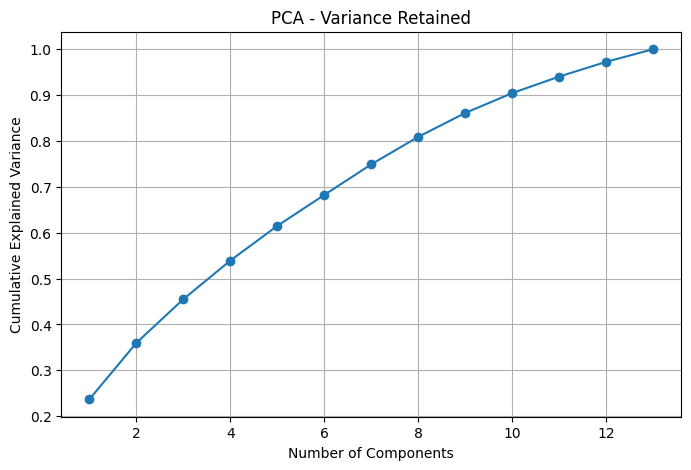

In [4]:
# Explained variance plot
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Variance Retained")
plt.grid()
plt.show()

In [5]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

n_components = np.argmax(cumulative_variance >= 0.95) + 1

print("Optimal components:", n_components)

Optimal components: 12


In [6]:
pca_opt = PCA(n_components=n_components)
X_pca_opt = pca_opt.fit_transform(X_scaled)

In [7]:
pca_df = pd.DataFrame(X_pca_opt)
pca_df["target"] = df["target"].values

pca_df.to_csv("../data/heart_pca.csv", index=False)

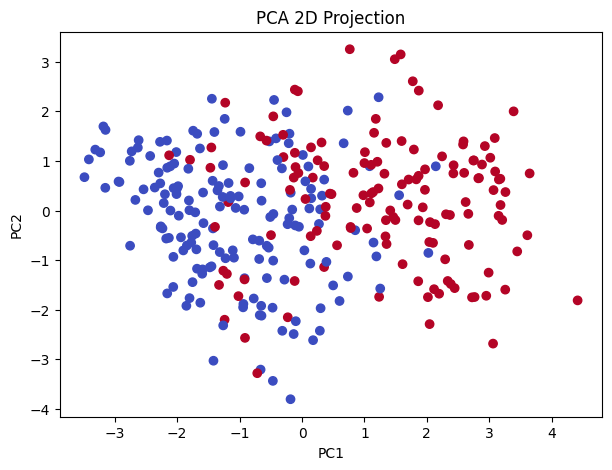

In [8]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=y, cmap="coolwarm")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Projection")
plt.show()